In [3]:
# Import des donnees
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/accidents_clean.csv")
df.head()

,obs,obsm,choc,manv,motor,place,catu,grav,sexe,trajet,...,circ,prof,plan,surf,infra,situ,vma,age,equipements,catv_regroup
0,0.0,2.0,5.0,23,1,2.0,2,2,2,0.0,...,3.0,1.0,2.0,1.0,2.0,1.0,70,17.0,"[1.0, 0.0]",5.0
1,0.0,2.0,5.0,23,1,1.0,1,2,2,5.0,...,3.0,1.0,2.0,1.0,2.0,1.0,70,26.0,"[1.0, 0.0]",5.0
2,1.0,0.0,3.0,11,1,1.0,1,1,1,0.0,...,3.0,1.0,2.0,1.0,2.0,1.0,70,60.0,"[1.0, 0.0]",6.0
3,4.0,0.0,1.0,0,1,1.0,1,2,2,0.0,...,1.0,4.0,2.0,1.0,0.0,1.0,70,25.0,"[1.0, 0.0]",5.0
4,0.0,2.0,1.0,2,1,1.0,1,1,1,0.0,...,3.0,1.0,3.0,1.0,0.0,1.0,90,23.0,"[1.0, 0.0]",5.0


In [6]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder


df_chi = df.copy()

# Séparer features et target
X = df_chi.drop(columns='grav')
y = df_chi['grav']

# Encodage des variables catégorielles
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Exemple de transformation : convertir une année de naissance
if 'an_naiss' in X.columns:
    X['age'] = 2025 - X['an_naiss']
    X.drop(columns='an_naiss', inplace=True)

# Supprimer toutes les colonnes contenant des valeurs négatives (si non réparable)
X = X.loc[:, (X >= 0).all()]

# Application de chi²
selector = SelectKBest(score_func=chi2, k='all')
X_new = selector.fit_transform(X, y)

# Résultats
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print("Scores chi² des variables :")
print(scores)

Scores chi² des variables :
com             3.404130e+07
obs             2.335451e+05
dep             1.324898e+05
equipements     1.284982e+05
place           1.034106e+05
age             9.626779e+04
hrmn            8.576102e+04
vma             7.079766e+04
catv_regroup    4.270049e+04
manv            3.688832e+04
obsm            1.902388e+04
motor           1.190278e+04
situ            1.105149e+04
catu            9.709115e+03
col             8.882823e+03
choc            4.256088e+03
trajet          3.621016e+03
int             3.093086e+03
plan            2.981559e+03
agg             2.743997e+03
sexe            8.956734e+02
lum             8.245223e+02
prof            6.424510e+02
atm             5.153885e+02
surf            2.873693e+02
catr            2.711663e+02
infra           2.068809e+02
circ            1.734766e+02
jour            5.618646e+01
mois            9.073892e+00
an              1.763771e-01
dtype: float64


In [7]:
from sklearn.feature_selection import f_classif
#Anova
# Sélection des variables numériques
X_num = df.select_dtypes(include=['int64', 'float64']).drop(columns='grav')
y_num = df['grav']

# Application du test ANOVA
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X_num, y_num)

# Résultat
anova_scores = pd.DataFrame({
    'Feature': X_num.columns,
    'F-Score': anova_selector.scores_,
    'p-value': anova_selector.pvalues_
}).sort_values(by='F-Score', ascending=False)

print("\nRésultats du test ANOVA :")
print(anova_scores)


Résultats du test ANOVA :
         Feature       F-Score        p-value
28  catv_regroup  33950.892975   0.000000e+00
6           catu  12094.229015   0.000000e+00
5          place  11295.815418   0.000000e+00
0            obs   8548.782749   0.000000e+00
1           obsm   7325.860824   0.000000e+00
13           agg   6572.612536   0.000000e+00
4          motor   4554.205269   0.000000e+00
27           age   3511.188733   0.000000e+00
16           col   3337.097064   0.000000e+00
22          plan   2977.508457   0.000000e+00
26           vma   2794.768336   0.000000e+00
25          situ   2710.151398   0.000000e+00
7           sexe   1830.913913   0.000000e+00
3           manv   1361.633801   0.000000e+00
21          prof    899.929991   0.000000e+00
2           choc    713.446233   0.000000e+00
14           int    556.546958   0.000000e+00
8         trajet    539.388884   0.000000e+00
17           lat    340.147859  9.811034e-221
20          circ    323.892090  3.587436e-210
12     

In [11]:
# j'essaie un SlectKbest
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


# Encodage des colonnes catégorielles
df_model = df.copy()
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# Séparation X/y
X = df_model.drop(columns=['grav'])
y = df_model['grav']

# Sélection automatique des 10 meilleures variables avec ANOVA f_classif
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

# Variables retenues
selected_features = X.columns[selector.get_support()]
print("Variables sélectionnées :", list(selected_features))

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42, stratify=y)

# Modèle RandomForest sur variables sélectionnées
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Prédictions et évaluation
y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Variables sélectionnées : ['obs', 'obsm', 'motor', 'place', 'catu', 'com', 'agg', 'col', 'age', 'catv_regroup']
Confusion Matrix:
[[41737 11544  2102   260]
 [13113 32877  5943   551]
 [ 2740  8313  8200   716]
 [  408  1186  1360   432]]

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.75      0.73     55643
           2       0.61      0.63      0.62     52484
           3       0.47      0.41      0.44     19969
           4       0.22      0.13      0.16      3386

    accuracy                           0.63    131482
   macro avg       0.50      0.48      0.49    131482
weighted avg       0.62      0.63      0.63    131482



grav
1    0.511536
2    0.346980
3    0.118283
4    0.023201
Name: proportion, dtype: float64


AttributeError: module 'matplotlib' has no attribute 'title'

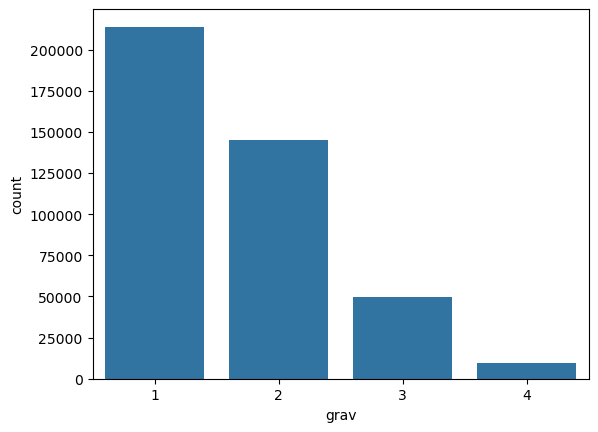

In [14]:
#Analyse uniquement sur les veh leger, cat5 de catv_regroupe
import seaborn as sns 
import matplotlib as plt

df_voitures = df[df['catv_regroup'] == 5].copy()
print(df_voitures['grav'].value_counts(normalize=True))
sns.countplot(data=df_voitures, x='grav')
plt.title("Répartition des classes de gravité (voitures uniquement)")
plt.show()

grav
1    0.423201
2    0.399175
3    0.151874
4    0.025750
Name: proportion, dtype: float64


AttributeError: module 'matplotlib' has no attribute 'title'

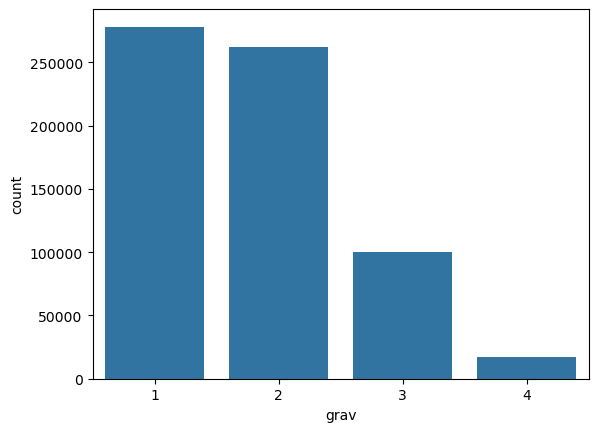

In [18]:
import seaborn as sns 
import matplotlib as plt


print(df['grav'].value_counts(normalize=True))
sns.countplot(data=df, x='grav')
plt.title("Répartition des classes de gravité (voitures uniquement)")
plt.show()

In [16]:
# Test avec un oversampling sur les voiture
from imblearn.over_sampling import RandomOverSampler

X = df_voitures  # Tes variables sélectionnées
y = df_voitures['grav']    # Cible

# Encodage si nécessaire
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("Répartition après oversampling :")
print(pd.Series(y_res).value_counts())

Répartition après oversampling :
grav
2    213980
1    213980
3    213980
4    213980
Name: count, dtype: int64


=== Confusion Matrix ===
[[29593 10221  2586   396]
 [ 8007 30932  3377   480]
 [  358   685 41575   178]
 [    0     0     6 42790]]

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.78      0.69      0.73     42796
           2       0.74      0.72      0.73     42796
           3       0.87      0.97      0.92     42796
           4       0.98      1.00      0.99     42796

    accuracy                           0.85    171184
   macro avg       0.84      0.85      0.84    171184
weighted avg       0.84      0.85      0.84    171184



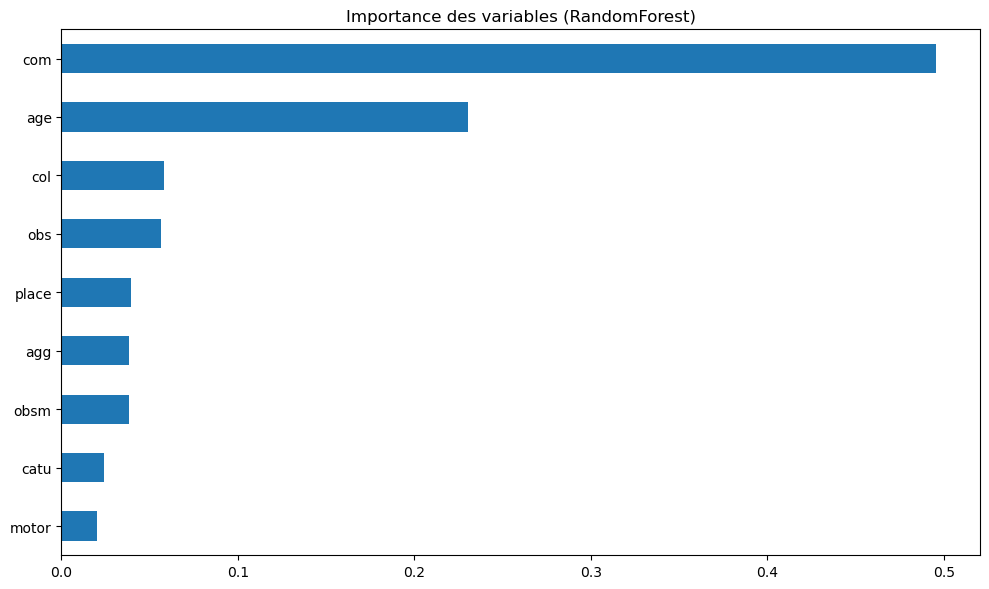

In [17]:
#RandomForest sur voiture
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

# 1. Filtrer uniquement les voitures
df_voitures = df[df['catv_regroup'] == 5].copy()

# 2. Définir les variables à utiliser (à adapter selon ton analyse)
features = ['obs', 'obsm', 'motor', 'place', 'catu', 'com', 'agg', 'col', 'age']
target = 'grav'

df_model = df_voitures[features + [target]].copy()

# 3. Encodage des variables catégorielles
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# 4. Séparation X et y
X = df_model.drop(columns=target)
y = df_model[target]

# 5. Oversampling pour équilibrer les classes
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# 6. Séparation en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 7. Entraînement du modèle RandomForest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 8. Prédiction
y_pred = rf.predict(X_test)

# 9. Évaluation
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 10. (Optionnel) Affichage des importances des features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Importance des variables (RandomForest)")
plt.tight_layout()
plt.show()

=== Confusion Matrix ===
[[34971 14590  5309   773]
 [15114 31250  7954  1325]
 [ 2146  3111 49810   577]
 [   18     9     5 55611]]

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.67      0.63      0.65     55643
           2       0.64      0.56      0.60     55643
           3       0.79      0.90      0.84     55644
           4       0.95      1.00      0.98     55643

    accuracy                           0.77    222573
   macro avg       0.76      0.77      0.77    222573
weighted avg       0.76      0.77      0.77    222573



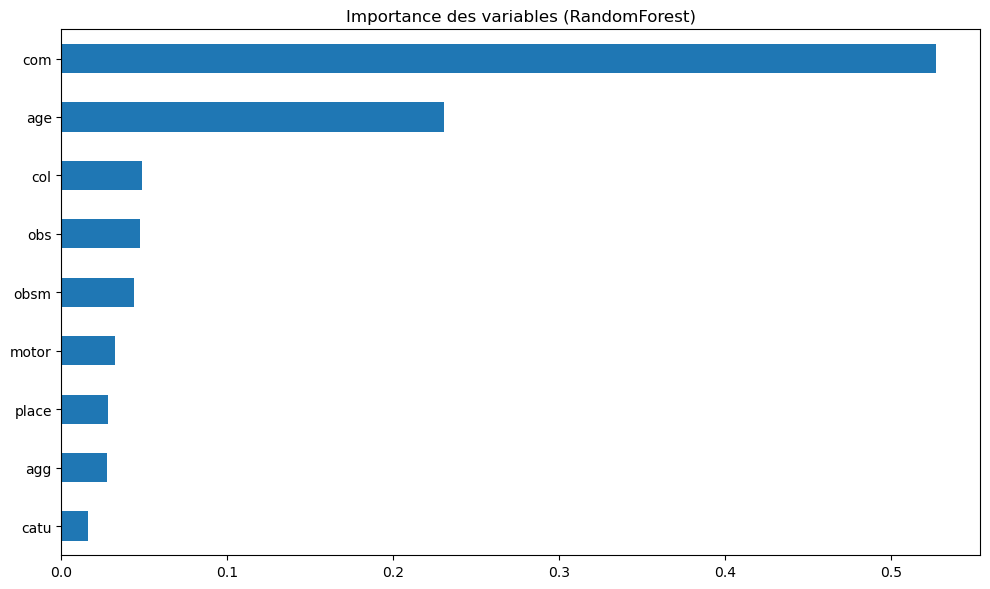

In [ ]:
#RandomForest sur voiture
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler

# 1. Filtrer uniquement les voitures

# 2. Définir les variables à utiliser 
features = ['obs', 'obsm', 'motor', 'place', 'catu', 'com', 'agg', 'col', 'age']
target = 'grav'

df_model = df[features + [target]].copy()

# 3. Encodage des variables catégorielles
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# 4. Séparation X et y
X = df_model.drop(columns=target)
y = df_model[target]

# 5. Oversampling pour équilibrer les classes
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# 6. Séparation en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# 7. Entraînement du modèle RandomForest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 8. Prédiction
y_pred = rf.predict(X_test)

# 9. Évaluation
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 10. (Optionnel) Affichage des importances des features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Importance des variables (RandomForest)")
plt.tight_layout()
plt.show()